In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
rfm = pd.read_csv(
    "../data/processed/customer_segments.csv"
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,High-Value Customers
1,12347.0,2,7,4310.00,0,Regular Customers
2,12348.0,75,4,1797.24,0,Regular Customers
3,12349.0,19,1,1757.55,0,Regular Customers
4,12350.0,310,1,334.40,1,At-Risk Customers


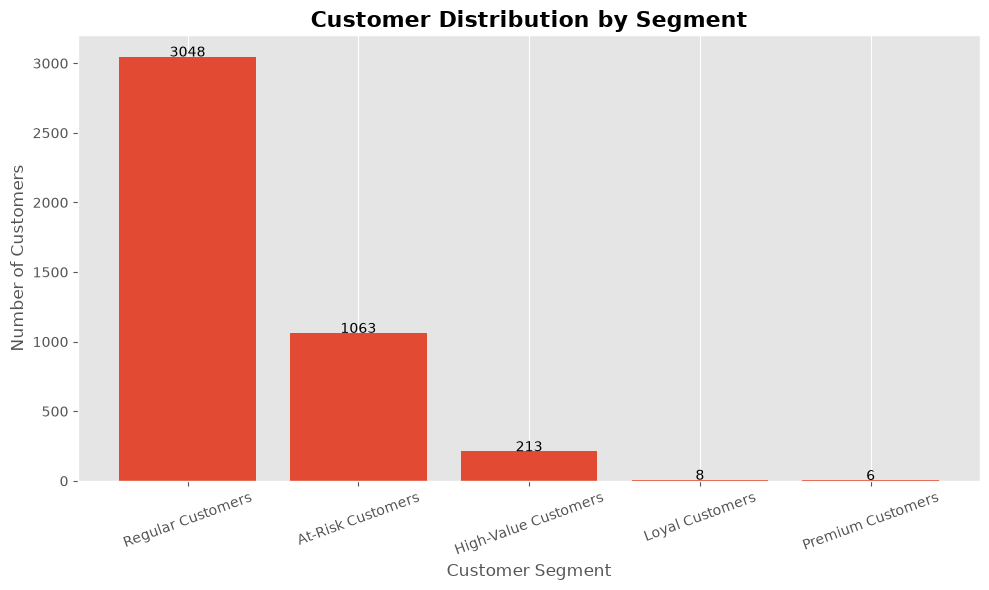

In [3]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title(
    "Customer Distribution by Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.grid(axis="y")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        str(int(height)),
        ha="center"
    )

plt.tight_layout()

plt.show()

In [4]:
cluster_profile = (

    rfm.groupby("Segment")[

        ["Recency","Frequency","Monetary"]

    ].mean()

)

cluster_profile

,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,248.469426,1.553151,478.648242
High-Value Customers,15.671362,21.286385,12813.941596
Loyal Customers,6.500000,120.500000,55099.491250
Premium Customers,7.666667,42.833333,190808.536667
Regular Customers,43.918635,3.650262,1333.132908


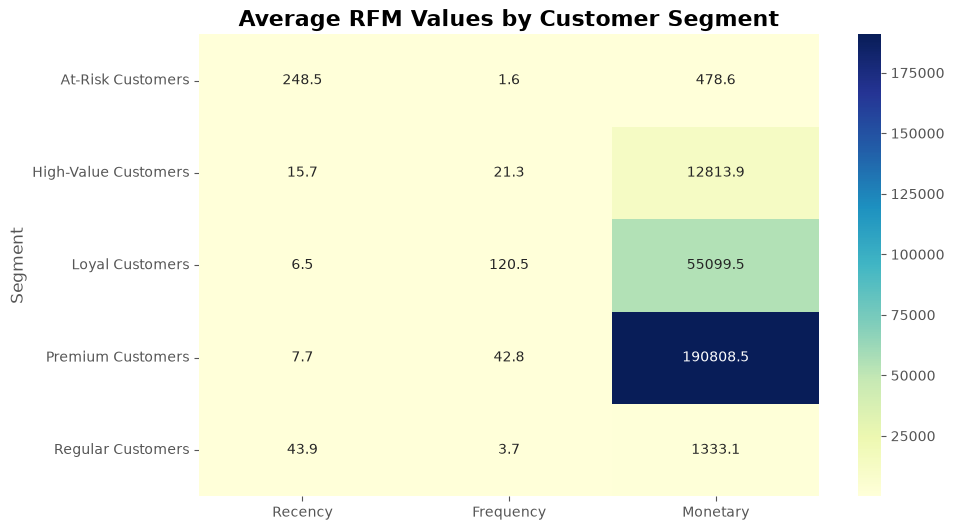

In [5]:
plt.figure(figsize=(10,6))

sns.heatmap(

    cluster_profile,

    annot=True,

    cmap="YlGnBu",

    fmt=".1f"

)

plt.title(

    "Average RFM Values by Customer Segment",

    fontsize=16,

    fontweight="bold"

)

plt.show()

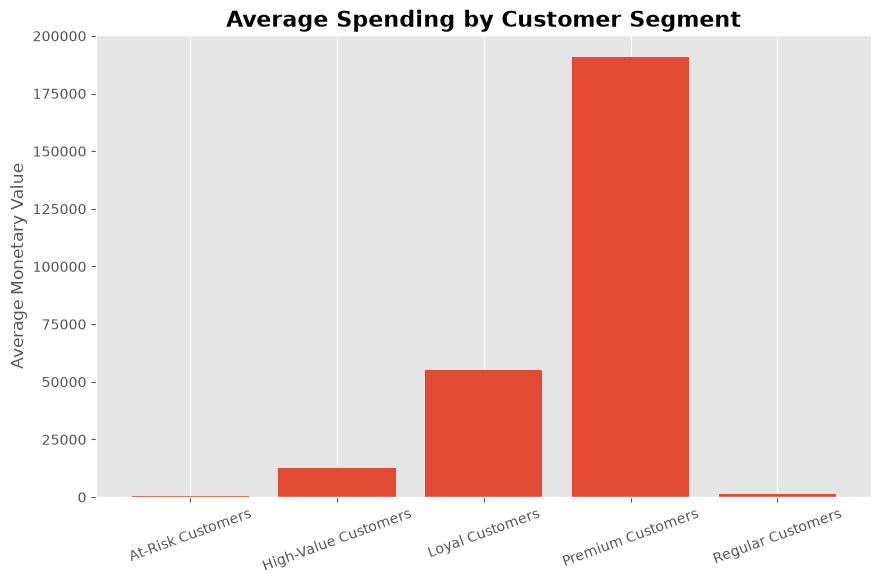

In [6]:
plt.figure(figsize=(10,6))

bars = plt.bar(

    cluster_profile.index,

    cluster_profile["Monetary"]

)

plt.title(

    "Average Spending by Customer Segment",

    fontsize=16,

    fontweight="bold"

)

plt.ylabel("Average Monetary Value")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

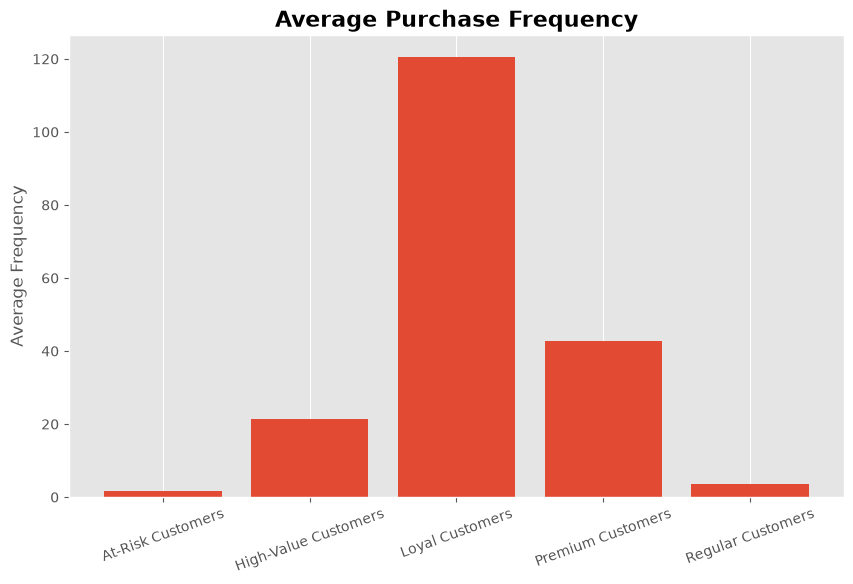

In [7]:
plt.figure(figsize=(10,6))

plt.bar(

    cluster_profile.index,

    cluster_profile["Frequency"]

)

plt.title(

    "Average Purchase Frequency",

    fontsize=16,

    fontweight="bold"

)

plt.ylabel("Average Frequency")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

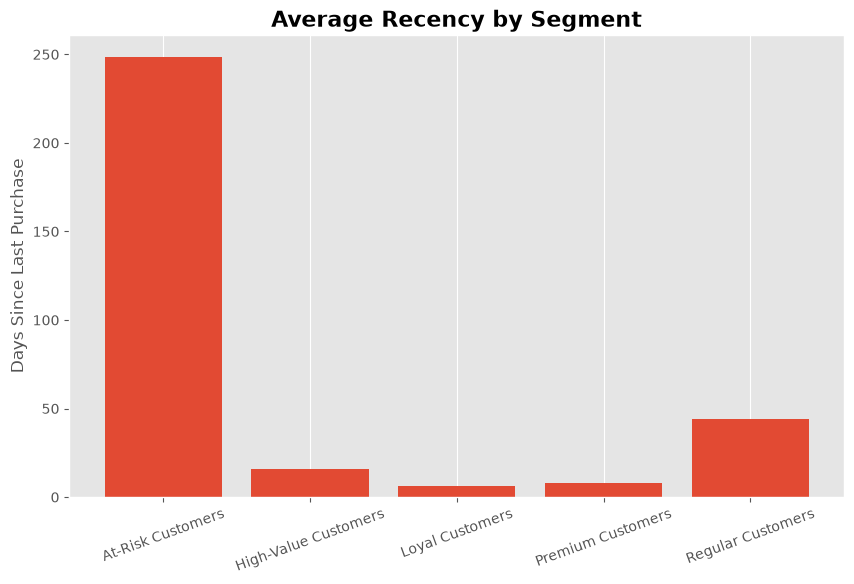

In [8]:
plt.figure(figsize=(10,6))

plt.bar(

    cluster_profile.index,

    cluster_profile["Recency"]

)

plt.title(

    "Average Recency by Segment",

    fontsize=16,

    fontweight="bold"

)

plt.ylabel("Days Since Last Purchase")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

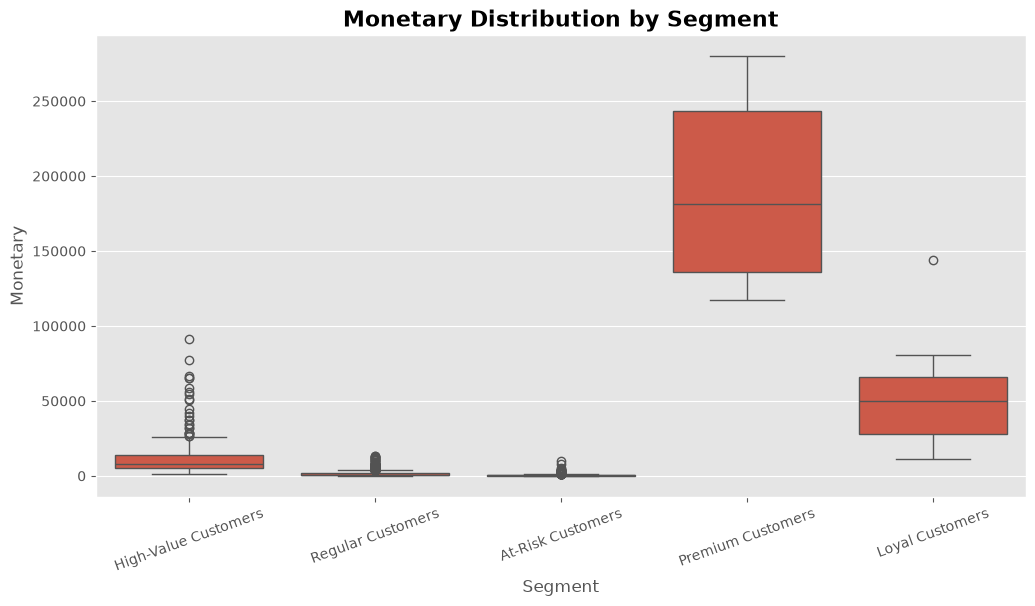

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(

    x="Segment",

    y="Monetary",

    data=rfm

)

plt.xticks(rotation=20)

plt.title(

    "Monetary Distribution by Segment",

    fontsize=16,

    fontweight="bold"

)

plt.show()

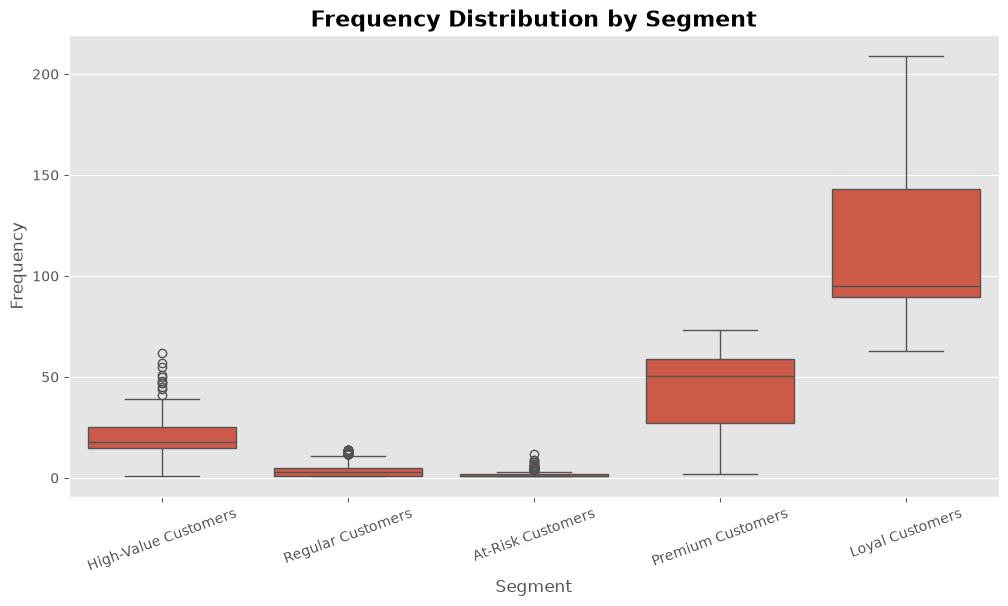

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(

    x="Segment",

    y="Frequency",

    data=rfm

)

plt.xticks(rotation=20)

plt.title(

    "Frequency Distribution by Segment",

    fontsize=16,

    fontweight="bold"

)

plt.show()

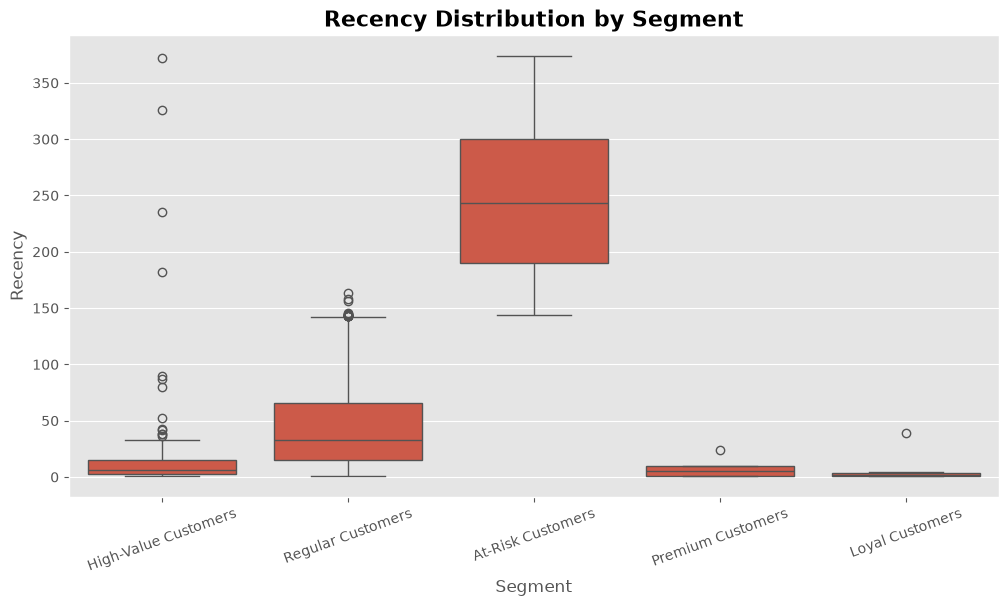

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(

    x="Segment",

    y="Recency",

    data=rfm

)

plt.xticks(rotation=20)

plt.title(

    "Recency Distribution by Segment",

    fontsize=16,

    fontweight="bold"

)

plt.show()

In [12]:
summary = pd.DataFrame({

    "Customer Count": rfm.groupby("Segment").size(),

    "Average Recency": rfm.groupby("Segment")["Recency"].mean(),

    "Average Frequency": rfm.groupby("Segment")["Frequency"].mean(),

    "Average Monetary": rfm.groupby("Segment")["Monetary"].mean()

}).round(2)

summary

,Customer Count,Average Recency,Average Frequency,Average Monetary
Segment,,,,
At-Risk Customers,1063,248.47,1.55,478.65
High-Value Customers,213,15.67,21.29,12813.94
Loyal Customers,8,6.50,120.50,55099.49
Premium Customers,6,7.67,42.83,190808.54
Regular Customers,3048,43.92,3.65,1333.13


In [13]:
summary.to_csv(

    "../reports/customer_segment_summary.csv"

)

| Segment              | Recommendation                                                                                 |
| -------------------- | ---------------------------------------------------------------------------------------------- |
| High-Value Customers | Provide VIP membership, personalized offers, early access to new products.                     |
| Premium Customers    | Offer dedicated support, exclusive rewards, and premium experiences to retain them.            |
| Loyal Customers      | Encourage referrals, reward repeat purchases, and strengthen loyalty programs.                 |
| Regular Customers    | Use cross-selling, upselling, and personalized recommendations to increase purchase frequency. |
| At-Risk Customers    | Launch win-back campaigns, targeted discounts, and reminder emails to reduce churn.            |
